# March Madness LSTM Recurrent Model

This notebook builds an LSTM-based recurrent neural network to predict game outcomes using:
1. **Team Encoder**: LSTM to encode each team's historical stats to a latent vector
2. **Prediction Head**: Binary classifier combining two team embeddings
3. **Walk-Forward Training**: Temporal validation preventing future leakage

## Setup and Configuration

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from tqdm import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set seeds for reproducibility
import os, random
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Libraries imported")
print(f"  Device: {device}")

✓ Libraries imported
  Device: cuda


## Hyperparameters

In [13]:
# Model hyperparameters (easily adjustable)
CONFIG = {
    # Model architecture
    'latent_dim': 32,              # Dimensionality of team latent vector
    'hidden_dim': 64,             # LSTM hidden dimension
    'num_layers': 3,               # Number of LSTM layers
    'dropout': 0.3,                # Dropout rate
    
    # Training
    'batch_size': 32,
    'learning_rate': 1e-3,
    'epochs': 3,
}


## 1. Load and Prepare Data

In [14]:
# Load processed data
df = pd.read_csv("./InputData2023.csv")
df = df.sort_values(by='Date').reset_index(drop=True)

# Standardize statistics
stat1 = sorted([c for c in df.columns if c.startswith('1-')])
stat2 = [c.replace('1-','2-') for c in stat1]

train_mask = (df['is_tournament_game'] == False)
mu = df.loc[train_mask, stat1].mean()
sd = df.loc[train_mask, stat1].std().replace(0, 1)

df.loc[:, stat1] = (df[stat1] - mu) / sd
df.loc[:, stat2] = (df[stat2] - mu.values) / sd.values

df.columns

Index(['Game ID', 'Team 1', 'Team 2', 'Date', 'Site', 'Outcome', 'is_tournament_game', '1-ORtg', '1-DRtg', '1-3PAr', '1-TS%', '1-TRB%', '1-AST%', '1-STL%', '1-BLK%', '1-eFG%', '1-TOV%', '1-ORB%', '1-FTr', '1-oeFG%', '1-oTOV%', '1-oDRB%', '1-oFTr', '1-Pace', '1-o3PAr', '2-ORtg', '2-DRtg', '2-3PAr', '2-TS%', '2-TRB%', '2-AST%', '2-STL%', '2-BLK%', '2-eFG%', '2-TOV%', '2-ORB%', '2-FTr', '2-oeFG%', '2-oTOV%', '2-oDRB%', '2-oFTr', '2-Pace', '2-o3PAr'], dtype='object')

## 2. Team Encoder LSTM Model

In [15]:
class TeamEncoder(nn.Module):
    """Encodes a team's game history to a latent vector using LSTM."""
    
    def __init__(self, input_size, hidden_dim, num_layers, latent_dim, dropout=0.1):
        super(TeamEncoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.latent_dim = latent_dim
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Project LSTM output to latent space
        self.projection = nn.Linear(hidden_dim*2, latent_dim)

    def forward(self, x, lengths):
        clamped = lengths.clamp(min=1)
        packed = pack_padded_sequence(x, clamped.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, _) = self.lstm(packed)
        out, _ = pad_packed_sequence(packed_out, batch_first=True)   # (B, Lmax, H)

        # build mask: 1 for real steps, 0 for pad
        B, Lmax, H = out.shape
        device = out.device
        mask = torch.arange(Lmax, device=device).unsqueeze(0) < lengths.unsqueeze(1)  # (B,Lmax)
        mask = mask.float().unsqueeze(-1)  # (B,Lmax,1)

        # masked mean over time
        sum_out = (out * mask).sum(dim=1)                  # (B,H)
        len_f = lengths.clamp(min=1).float().unsqueeze(1)  # (B,1)
        mean_out = sum_out / len_f

        last_hidden = h_n[-1]  # (B,H)

        # combine last + mean then project
        combined = torch.cat([last_hidden, mean_out], dim=1)      # (B, 2H)
        self.projection = getattr(self, "projection", nn.Linear(2*self.hidden_dim, self.latent_dim)).to(device)
        latent = self.projection(combined)

        # zero out for zero-length sequences
        latent = latent.masked_fill((lengths == 0).unsqueeze(1).to(device), 0.0)
        return latent


class PredictionHead(nn.Module):
    """Binary classifier head that combines two team embeddings."""
    
    def __init__(self, latent_dim, hidden_dim=64, dropout=0.1):
        super(PredictionHead, self).__init__()
        
        # Take difference between teams as input
        self.fc1 = nn.Linear(latent_dim * 2, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, 1)


    def forward(self, team_a_latent, team_b_latent):
        """
        Args:
            team_a_latent: (batch_size, latent_dim)
            team_b_latent: (batch_size, latent_dim)
        Returns:
            prob: (batch_size, 1) - probability team A wins
        """
        x = torch.cat([team_a_latent, team_b_latent], dim=1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)             # (batch,1)
        
        return logits


class RecurrentGamePredictor(nn.Module):
    """Complete model: team encoders + prediction head."""
    
    def __init__(self, input_size, hidden_dim, num_layers, latent_dim, dropout=0.3):
        super(RecurrentGamePredictor, self).__init__()
        
        # Shared team encoder
        self.encoder = TeamEncoder(
            input_size=input_size,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            latent_dim=latent_dim,
            dropout=dropout
        )
        
        # Prediction head
        self.head = PredictionHead(latent_dim, hidden_dim=hidden_dim, dropout=dropout)
        
    def forward(self, team_a_seq, len_a, team_b_seq, len_b):
        """
        Args:
            team_a_seq: (batch_size, seq_length, input_size)
            team_b_seq: (batch_size, seq_length, input_size)
        Returns:
            prob: (batch_size, 1) - probability team A wins
        """
        team_a_latent = self.encoder(team_a_seq, len_a)
        team_b_latent = self.encoder(team_b_seq, len_b)
        prob = self.head(team_a_latent, team_b_latent)
        return prob, team_a_latent, team_b_latent


print("✓ Model architecture defined")
print(f"  TeamEncoder: LSTM({CONFIG['hidden_dim']}) -> Linear({CONFIG['latent_dim']})")
print(f"  PredictionHead: Concat(2×{CONFIG['latent_dim']}) -> Binary")

✓ Model architecture defined
  TeamEncoder: LSTM(64) -> Linear(32)
  PredictionHead: Concat(2×32) -> Binary


## 3. Data Preparation for Walk-Forward Training

In [16]:
class GameSequenceDataset(torch.utils.data.Dataset):
    """
    PyTorch Dataset for NCAA basketball games with pre-built sequential arrays.
    
    For each game, returns:
    - team_1_seq: (n_prev_games1, n_features) - Team 1's previous games
    - team_2_seq: (n_prev_games2, n_features) - Team 2's previous games  
    - outcome: 0 or 1 (Team 1 win?)
    
    Uses pre-built arrays and slicing for fast access.
    """
    
    def __init__(self, df, use_indices=None):
        """
        Args:
            df: DataFrame with columns: Team 1, Team 2, Date, Site, Outcome, 
                1-ORtg, 1-DRtg, ... (stats prefixed with 1- and 2-)
        """
        self.df = df.reset_index(drop=True)
        
        # Auto-detect stat columns
        self.stat_cols = sorted([col for col in df.columns if col.startswith('1-')])
        self.stat_cols_team2 = [col.replace('1-', '2-') for col in self.stat_cols]
        self.team_games = defaultdict(list)

        # Feature engineering
        self._prepare_features()
        
        # Build sequential arrays from ALL games
        self._build_sequential_arrays()
        
        # Set which indices this dataset will expose
        if use_indices is not None:
            self.active_indices = use_indices
        else:
            self.active_indices = list(range(len(self.df)))


    def __len__(self):
        return len(self.active_indices)

    def n_features(self):
        return len(self.stat_cols)

    def _prepare_features(self):
        """Encode categorical variables and sort chronologically."""
        # 1. Encode Team names
        unique_teams = pd.concat([self.df['Team 1'], self.df['Team 2']]).unique()
        self.team_encoder = {team: idx for idx, team in enumerate(sorted(unique_teams))}
        self.n_teams = len(self.team_encoder)
        self.df['Team 1'] = self.df['Team 1'].map(self.team_encoder)
        self.df['Team 2'] = self.df['Team 2'].map(self.team_encoder)
        
        # # 2. Encode Site
        # site_map = {'home': 1.0, 'away': 0.0, 'neutral': 0.5}
        # self.df['1-Site'] = self.df['Site'].map(site_map).fillna(0.5)

        # # For Team 2, reverse the mapping (home<->away)
        # inv_site_map = {'home': 0.0, 'away': 1.0, 'neutral': 0.5}
        # self.df['2-Site'] = self.df['Site'].map(inv_site_map).fillna(0.5)
        
        # self.stat_cols.append('1-Site')
        # self.stat_cols_team2.append('2-Site')
        
        # 3. Sort by date
        self.df['Date'] = pd.to_datetime(self.df['Date'])
    
    def _build_sequential_arrays(self):
        """
        Pre-build arrays for each team containing their game stats in order.
        
        Creates:
        - self.team_arrays: dict[team_id -> (n_games, n_features) array]
        - self.team_game_map: dict[team_id -> list of (global_idx, local_idx)]
        """
        
        # First pass: collect all games for each team
        for game_idx, row in self.df.iterrows():
            team_1 = row['Team 1']
            team_2 = row['Team 2']
            
            # Store (game_idx, stats, is_team1)
            stats_1 = row[self.stat_cols].values.astype(np.float32)
            stats_2 = row[self.stat_cols_team2].values.astype(np.float32)

            self.team_games[team_1].append((game_idx, stats_1))
            self.team_games[team_2].append((game_idx, stats_2))

  

    def _get_team_sequence(self, team_id, current_game_idx, max_prev_games=10):
        """
        Get previous games for a team using array slicing.
        
        Args:
            team_id: Team identifier
            current_game_idx: Index of current game in df
        
        Returns:
            np.array: (n_prev_games, n_features) - historical stats
        """
        all_game = self.team_games[team_id]
        # Filter to only games before current_game_idx
        prev_games = [stats for (g_idx, stats) in all_game if g_idx < current_game_idx]
        if len(prev_games) == 0:
            return np.zeros((0, self.n_features()), dtype=np.float32)
        prev_games = prev_games[-max_prev_games:] if max_prev_games > 0 else prev_games
        return np.stack(prev_games, axis=0)
    

    def __getitem__(self, idx):
        """
        Returns:
            (team_1_seq, team_2_seq, outcome)
            - team_1_seq: (n_prev_games_1, n_features) - ALL Team 1 history
            - team_2_seq: (n_prev_games_2, n_features) - ALL Team 2 history
            - outcome: 0 or 1
            
        Note: Sequences are variable length! Use collate_fn for batching.
        """
        actual_idx = self.active_indices[idx]
        row = self.df.loc[actual_idx]
        
        team_1 = row['Team 1']
        team_2 = row['Team 2']
        outcome = int(row['Outcome'])
        
        # Get historical sequences (uses ALL games in self.team_games)
        team_1_seq = self._get_team_sequence(team_1, actual_idx)
        team_2_seq = self._get_team_sequence(team_2, actual_idx)
        
        return (
            torch.FloatTensor(team_1_seq),
            torch.FloatTensor(team_2_seq),
            torch.LongTensor([outcome])
        )

# Custom collate function for variable-length sequences
def collate_variable_length(batch):
    team_a_seqs, team_b_seqs, outcomes = zip(*batch)

    lens_a = torch.tensor([s.shape[0] for s in team_a_seqs], dtype=torch.long)
    lens_b = torch.tensor([s.shape[0] for s in team_b_seqs], dtype=torch.long)

    n_features = team_a_seqs[0].shape[1] if team_a_seqs[0].numel() > 0 else team_b_seqs[0].shape[1]
    bs = len(batch)

    max_len_a = max(lens_a.max().item(), 1)
    max_len_b = max(lens_b.max().item(), 1)

    pad_a = torch.zeros(bs, max_len_a, n_features)
    pad_b = torch.zeros(bs, max_len_b, n_features)

    for i, (sa, sb) in enumerate(zip(team_a_seqs, team_b_seqs)):
        if sa.shape[0] > 0: pad_a[i, :sa.shape[0]] = sa
        if sb.shape[0] > 0: pad_b[i, :sb.shape[0]] = sb

    y = torch.cat(outcomes, dim=0).view(-1, 1).long()

    return pad_a, lens_a, pad_b, lens_b, y

## 4. Execute Walk-Forward Validation

In [17]:
train_indices = df[df['is_tournament_game'] == False].index.tolist()
test_indices = df[df['is_tournament_game'] == True].index.tolist()

# Create datasets
train_dataset = GameSequenceDataset(df, use_indices=train_indices)
test_dataset = GameSequenceDataset(df, use_indices=test_indices)

train_loader = DataLoader(train_dataset, CONFIG['batch_size'], shuffle=True, collate_fn=collate_variable_length)
test_loader = DataLoader(test_dataset, CONFIG['batch_size'], shuffle=False, collate_fn=collate_variable_length)

model = RecurrentGamePredictor(
    input_size=len(train_dataset.stat_cols),
    hidden_dim=CONFIG['hidden_dim'],
    num_layers=CONFIG['num_layers'],
    latent_dim=CONFIG['latent_dim'],
    dropout=CONFIG['dropout']
).to(device)

# Setup optimizer and loss
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

pbar = tqdm(range(CONFIG['epochs']), desc="Training Epochs")
for epoch in pbar:
    model.train()
    total_loss = 0
    
    for team_a_seq, len_a, team_b_seq, len_b, targets in train_loader:
        # Move to device
        team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
        team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
        targets = targets.to(device).view(-1, 1).float()

        # Forward pass
        logits, _, _ = model(team_a_seq, len_a, team_b_seq, len_b)
        optimizer.zero_grad()
        loss = criterion(logits, targets.float())
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step()
    pbar.set_postfix({'loss': f'{avg_loss:.4f}'})

print("\n✓ Training completed!")

Training Epochs: 100%|██████████| 3/3 [00:15<00:00,  5.12s/it, loss=0.6053]


✓ Training completed!


In [18]:
# Validation
model.eval()
test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False,
    collate_fn=collate_variable_length
)

all_probs = []
all_targets = []

with torch.no_grad():
    for team_a_seq, len_a, team_b_seq, len_b, targets in test_loader:
        team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
        team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
        targets = targets.to(device).view(-1, 1)
        logits, team_a_score, team_b_score = model(team_a_seq, len_a, team_b_seq, len_b)
        probs = torch.sigmoid(logits)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())   

all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

auc = roc_auc_score(all_targets, all_probs)
print(f"✓ Validation AUC: {auc:.4f}")

✓ Validation AUC: 0.6914


TEST SET EVALUATION
AUC Score:       0.6914
Accuracy:        0.6418
Total Samples:   67

Confusion Matrix:
                 Predicted
                 Loss  |  Win
Actual  Loss      15  |   13
        Win       11  |   28

Confusion Matrix (Percentages):
True Negatives:   15 (22.4%)
False Positives:  13 (19.4%)
False Negatives:  11 (16.4%)
True Positives:   28 (41.8%)

Classification Report:
              precision    recall  f1-score   support

    Loss (0)     0.5769    0.5357    0.5556        28
     Win (1)     0.6829    0.7179    0.7000        39

    accuracy                         0.6418        67
   macro avg     0.6299    0.6268    0.6278        67
weighted avg     0.6386    0.6418    0.6396        67



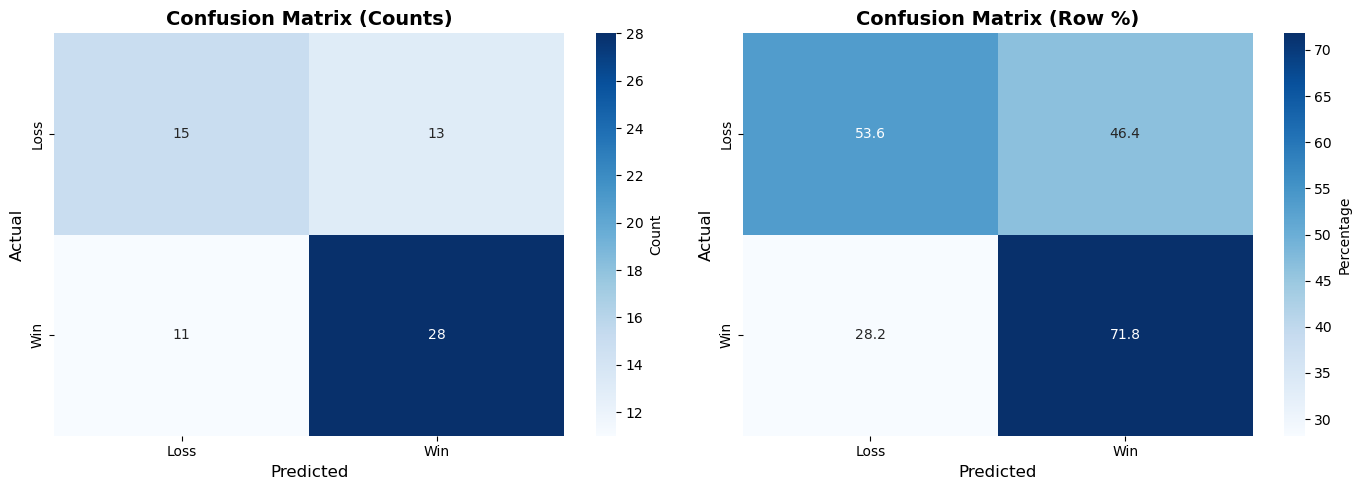

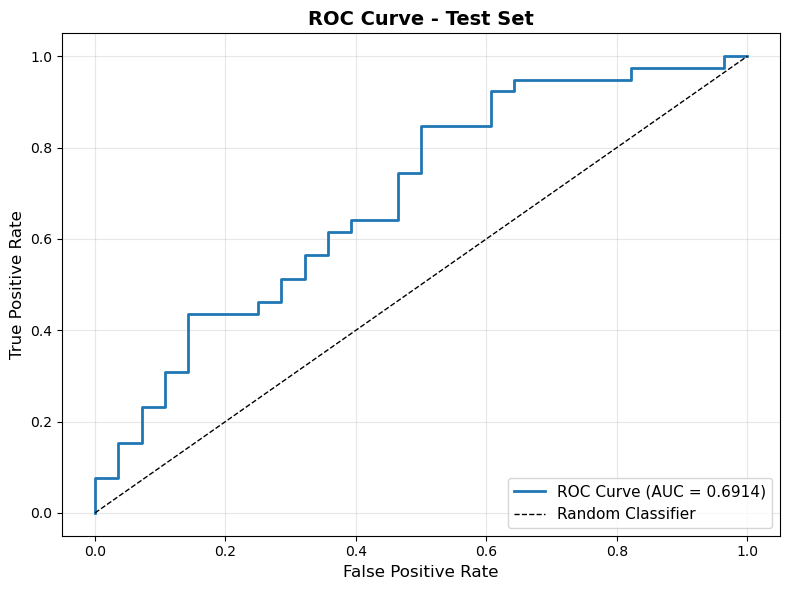

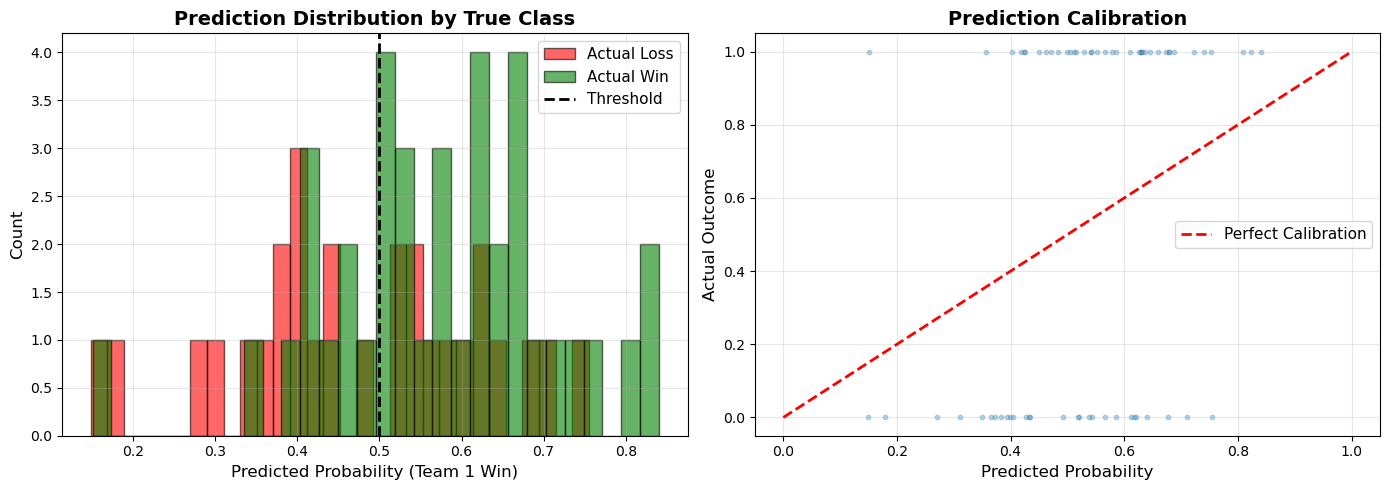

✓ Evaluation complete!


In [19]:
# Comprehensive Evaluation Metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Convert probabilities to binary predictions (threshold = 0.5)
all_preds = (all_probs > 0.5).astype(int)

# Compute metrics
accuracy = accuracy_score(all_targets, all_preds)
auc = roc_auc_score(all_targets, all_probs)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"AUC Score:       {auc:.4f}")
print(f"Accuracy:        {accuracy:.4f}")
print(f"Total Samples:   {len(all_targets)}")
print()

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
print("Confusion Matrix:")
print("                 Predicted")
print("                 Loss  |  Win")
print(f"Actual  Loss    {cm[0,0]:4d}  | {cm[0,1]:4d}")
print(f"        Win     {cm[1,0]:4d}  | {cm[1,1]:4d}")
print()

# Confusion matrix percentages
tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix (Percentages):")
print(f"True Negatives:   {tn} ({100*tn/len(all_targets):.1f}%)")
print(f"False Positives:  {fp} ({100*fp/len(all_targets):.1f}%)")
print(f"False Negatives:  {fn} ({100*fn/len(all_targets):.1f}%)")
print(f"True Positives:   {tp} ({100*tp/len(all_targets):.1f}%)")
print()

# Classification report
print("Classification Report:")
print(classification_report(all_targets, all_preds, 
                          target_names=['Loss (0)', 'Win (1)'],
                          digits=4))

# Visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap with counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Loss', 'Win'],
            yticklabels=['Loss', 'Win'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Heatmap with percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Loss', 'Win'],
            yticklabels=['Loss', 'Win'],
            ax=axes[1], cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Row %)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xlabel('Predicted', fontsize=12)

plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by true class
axes[0].hist(all_probs[all_targets.flatten() == 0], bins=30, alpha=0.6, 
             label='Actual Loss', color='red', edgecolor='black')
axes[0].hist(all_probs[all_targets.flatten() == 1], bins=30, alpha=0.6,
             label='Actual Win', color='green', edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[0].set_xlabel('Predicted Probability (Team 1 Win)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Prediction Distribution by True Class', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Calibration scatter
axes[1].scatter(all_probs, all_targets, alpha=0.3, s=10)
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Calibration')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Actual Outcome', fontsize=12)
axes[1].set_title('Prediction Calibration', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Evaluation complete!")


## Grid Search on Validation Set for Hyperparameter Tuning

Last 80 regular season games as validation

In [ ]:


import itertools
import json
from datetime import datetime

# Define grid search space
PARAM_GRID = {
    'latent_dim': [32, 64],
    'hidden_dim': [64, 128],
    'num_layers': [2, 3],
    'dropout': [0.3, 0.4, 0.5],
    'batch_size': [32, 64],
    'learning_rate': [1e-3, 5e-4],
    'max_prev_games': [5, 15, -1],
}

# Generate all combinations
param_combinations = list(itertools.product(*PARAM_GRID.values()))
param_names = list(PARAM_GRID.keys())

print(f"GRID SEARCH: {len(param_combinations)} configurations")


regular_season_indices = df[df['is_tournament_game'] == False].index.tolist()
test_indices = df[df['is_tournament_game'] == True].index.tolist()

val_size = 80
train_indices_gs = regular_season_indices[:-val_size]
val_indices_gs = regular_season_indices[-val_size:]


def train_and_evaluate_config(params_dict, train_idx, val_idx, df_data, n_epochs=3, patience=3):
    """Train model with given hyperparameters and return validation metrics."""
    
    # Custom dataset with max_prev_games
    class CustomDataset(GameSequenceDataset):
        def __init__(self, df, use_indices, max_games):
            super().__init__(df, use_indices)
            self.max_games = max_games
            
        def _get_team_sequence(self, team_id, current_game_idx, max_prev_games=None):
            if max_prev_games is None:
                max_prev_games = self.max_games
            return super()._get_team_sequence(team_id, current_game_idx, max_prev_games)
    
    train_ds = CustomDataset(df_data, train_idx, params_dict['max_prev_games'])
    val_ds = CustomDataset(df_data, val_idx, params_dict['max_prev_games'])
    
    train_loader = DataLoader(train_ds, params_dict['batch_size'], shuffle=True, collate_fn=collate_variable_length)
    val_loader = DataLoader(val_ds, params_dict['batch_size'], shuffle=False, collate_fn=collate_variable_length)
    
    model = RecurrentGamePredictor(
        input_size=len(train_ds.stat_cols),
        hidden_dim=params_dict['hidden_dim'],
        num_layers=params_dict['num_layers'],
        latent_dim=params_dict['latent_dim'],
        dropout=params_dict['dropout']
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=params_dict['learning_rate'], weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss()
    
    best_val_auc = 0
    patience_counter = 0
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        for team_a_seq, len_a, team_b_seq, len_b, targets in train_loader:
            team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
            team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
            targets = targets.to(device).view(-1, 1).float()
            
            optimizer.zero_grad()
            logits, _, _ = model(team_a_seq, len_a, team_b_seq, len_b)
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Validate
        model.eval()
        val_probs, val_targets = [], []
        with torch.no_grad():
            for team_a_seq, len_a, team_b_seq, len_b, targets in val_loader:
                team_a_seq, len_a = team_a_seq.to(device), len_a.to(device)
                team_b_seq, len_b = team_b_seq.to(device), len_b.to(device)
                targets = targets.to(device).view(-1, 1).float()
                
                logits, _, _ = model(team_a_seq, len_a, team_b_seq, len_b)
                probs = torch.sigmoid(logits)
                val_probs.append(probs.cpu().numpy())
                val_targets.append(targets.cpu().numpy())
        
        val_probs = np.concatenate(val_probs)
        val_targets = np.concatenate(val_targets)
        val_auc = roc_auc_score(val_targets, val_probs)
        val_acc = accuracy_score(val_targets, (val_probs > 0.5).astype(int))
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_acc = val_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    return {'val_auc': best_val_auc, 'val_acc': best_val_acc}

# %%
# Execute grid search
results = []
best_auc = 0
best_params = None

for i, param_values in enumerate(tqdm(param_combinations, desc="Grid Search")):
    params = dict(zip(param_names, param_values))
    
    try:
        metrics = train_and_evaluate_config(params, train_indices_gs, val_indices_gs, df, n_epochs=3, patience=3)
        result = {'params': params, **metrics}
        results.append(result)
        
        if metrics['val_auc'] > best_auc:
            best_auc = metrics['val_auc']
            best_params = params
    
    except Exception as e:
        results.append({'params': params, 'val_auc': 0, 'val_acc': 0, 'error': str(e)})

# Sort results
results_sorted = sorted(results, key=lambda x: x['val_auc'], reverse=True)

print(f"\n{'='*100}")
print("TOP 10 CONFIGURATIONS:")
print(f"{'='*100}")
print(f"{'Rank':<5} {'Val AUC':<10} {'Val Acc':<10} {'Parameters'}")
print(f"{'-'*100}")

for rank, result in enumerate(results_sorted[:10], 1):
    params_str = ", ".join([f"{k}={v}" for k, v in result['params'].items()])
    print(f"{rank:<5} {result['val_auc']:<10.4f} {result['val_acc']:<10.4f} {params_str}")

print(f"\nBEST: AUC={results_sorted[0]['val_auc']:.4f}, Params: {results_sorted[0]['params']}")

# Save results
with open('grid_search_results.json', 'w') as f:
    json.dump({'best_params': results_sorted[0]['params'], 'best_val_auc': results_sorted[0]['val_auc'], 
               'top_10': results_sorted[:10]}, f, indent=2)

print(f"✓ Results saved to grid_search_results.json")







GRID SEARCH: 288 configurations
Train: 5290 | Val: 80 | Test: 67


Grid Search: 100%|██████████| 288/288 [1:36:22<00:00, 20.08s/it]


TOP 10 CONFIGURATIONS:
Rank  Val AUC    Val Acc    Parameters
----------------------------------------------------------------------------------------------------
1     0.6473     0.6250     latent_dim=64, hidden_dim=128, num_layers=2, dropout=0.2, batch_size=32, learning_rate=0.001, max_prev_games=20
2     0.6213     0.6000     latent_dim=64, hidden_dim=128, num_layers=3, dropout=0.3, batch_size=32, learning_rate=0.0005, max_prev_games=10
3     0.6207     0.5750     latent_dim=32, hidden_dim=64, num_layers=2, dropout=0.4, batch_size=32, learning_rate=0.0005, max_prev_games=20
4     0.6133     0.5500     latent_dim=64, hidden_dim=64, num_layers=2, dropout=0.3, batch_size=32, learning_rate=0.0005, max_prev_games=15
5     0.6100     0.5250     latent_dim=64, hidden_dim=64, num_layers=2, dropout=0.3, batch_size=64, learning_rate=0.001, max_prev_games=10
6     0.6093     0.6000     latent_dim=32, hidden_dim=64, num_layers=3, dropout=0.4, batch_size=64, learning_rate=0.0005, max_prev_games

## Bracket Prediction

In [ ]:
def predict_bracket(model, dataset, team_matchups):
    """
    Predict tournament bracket given first round matchups.
    
    Args:
        model: Trained RecurrentGamePredictor model
        dataset: GameSequenceDataset instance with full historical data
        team_matchups: List of tuples (team1_name, team2_name) for first round
                      Should be 32 teams = 16 matchups
                      Order matters: Lower seed should be team1 (underdog)
    Returns:
        dict: Complete bracket with probabilities
    """
    model.eval()
    device = next(model.parameters()).device
    name_to_id = dataset.team_encoder

    # Use all history up to "now"
    current_game_idx = len(dataset.df)

    # Round name resolver from number of initial matchups
    round_order = ["Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Championship"]
    start_from_map = {32:0, 16:1, 8:2, 4:3, 2:4, 1:5}
    if len(team_matchups) not in start_from_map:
        raise ValueError("team_matchups length must be one of {32,16,8,4,2,1}.")
    start_idx = start_from_map[len(team_matchups)]

    # Prepare bracket container
    bracket = {rn: [] for rn in round_order[start_idx:]}
    bracket["Champion"] = None

    # Helpers
    def _team_seq(team_name):
        tid = name_to_id[team_name]
        seq = dataset._get_team_sequence(tid, current_game_idx)  # (L,F) possibly L=0
        if seq.shape[0] == 0:
            n_feat = dataset.n_features()
            seq = np.zeros((1, n_feat), dtype=np.float32)
            L = 1
        else:
            L = seq.shape[0]
        x = torch.tensor(seq, dtype=torch.float32, device=device).unsqueeze(0)   # (1,L,F)
        l = torch.tensor([L], dtype=torch.long, device=device)
        return x, l

    def _predict(a, b):
        with torch.no_grad():
            xa, la = _team_seq(a)
            xb, lb = _team_seq(b)
            logits, _, _ = model(xa, la, xb, lb)
            p_a = torch.sigmoid(logits).item()  # prob team A wins
        winner = a if p_a >= 0.5 else b
        conf = p_a if winner == a else 1.0 - p_a
        return p_a, winner, conf

    # Main single-loop over rounds
    pairs = team_matchups[:]  # list of (A,B)


    for round_name in round_order[start_idx:]:
        winners = []
        for (a, b) in pairs:
            p_a, winner, conf = _predict(a, b)
            bracket[round_name].append({
                "team1": a,
                "team2": b,
                "prob_team1": p_a,   # probability that the first team in the pair wins
                "winner": winner,
                "confidence": conf    # probability of the winner
            })
            winners.append(winner)
            print(f"{round_name}: {a} vs {b} => Winner: {winner} (P={p_a:.3f})")

        if len(winners) == 1:
            bracket["Champion"] = winners[0]
            break

        # Pair adjacent winners for the next round
        pairs = [(winners[i], winners[i+1]) for i in range(0, len(winners), 2)]

    return bracket

# Example bracket prediction (uncomment and modify team names)

In [ ]:
def extract_first_round_matchups(df):
    required = {"Team 1", "Team 2", "is_tournament_game"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    tourney_games = df[df["is_tournament_game"] == True].copy()
    first_round = tourney_games.head(32)

    # Build list of (Team 1, Team 2) tuples
    matchups = list(zip(first_round["Team 1"], first_round["Team 2"]))

    return matchups

In [ ]:
team_matchups = extract_first_round_matchups(df)
len(team_matchups)

32

In [ ]:
all_dataset = GameSequenceDataset(df)
bracket_prediction = predict_bracket(model, all_dataset, team_matchups)

Round of 64: Southeast Missouri State vs Texas A&M-Corpus Christi => Winner: Texas A&M-Corpus Christi (P=0.286)
Round of 64: Mississippi State vs Pittsburgh => Winner: Pittsburgh (P=0.468)
Round of 64: FDU vs Texas Southern => Winner: FDU (P=0.720)
Round of 64: Arizona State vs Nevada => Winner: Nevada (P=0.358)
Round of 64: Maryland vs West Virginia => Winner: Maryland (P=0.573)
Round of 64: Duke vs Oral Roberts => Winner: Oral Roberts (P=0.411)
Round of 64: College of Charleston vs San Diego State => Winner: College of Charleston (P=0.620)
Round of 64: Colgate vs Texas => Winner: Colgate (P=0.549)
Round of 64: Missouri vs Utah State => Winner: Utah State (P=0.420)
Round of 64: Furman vs Virginia => Winner: Virginia (P=0.486)
Round of 64: Penn State vs Texas A&M => Winner: Texas A&M (P=0.412)
Round of 64: Arizona vs Princeton => Winner: Arizona (P=0.680)
Round of 64: Alabama vs Texas A&M-Corpus Christi => Winner: Alabama (P=0.742)
Round of 64: Louisiana vs Tennessee => Winner: Tenness